In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load all required datasets
nav = pd.read_csv('../data/processed/clean_nav.csv')
transactions = pd.read_csv('../data/processed/clean_transactions.csv')
performance = pd.read_csv('../data/processed/clean_performance.csv')
fund_master = pd.read_csv('../data/raw/01_fund_master.csv')

# Fix date columns
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

print("✅ All datasets loaded!")
print(f"NAV shape: {nav.shape}")
print(f"Transactions shape: {transactions.shape}")
print(f"Performance shape: {performance.shape}")

✅ All datasets loaded!
NAV shape: (46000, 4)
Transactions shape: (32778, 14)
Performance shape: (40, 19)


In [3]:
# Sort data properly
nav = nav.sort_values(['amfi_code', 'date'])

# Compute daily return for each fund
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Drop first row of each fund (NaN return)
nav = nav.dropna(subset=['daily_return'])

print("✅ Daily returns computed!")
print(nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10))

✅ Daily returns computed!
    amfi_code       date       nav  daily_return
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776


In [4]:
# Risk-free rate (RBI repo rate proxy)
rf_daily = 0.065 / 252

results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    
    if len(returns) < 30:
        continue
    
    # Historical VaR at 95% confidence
    var_95 = np.percentile(returns, 5)
    
    # CVaR = average of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()
    
    # Annualised return
    ann_return = (1 + returns.mean()) ** 252 - 1
    
    # Annualised std dev
    ann_std = returns.std() * np.sqrt(252)
    
    # Sharpe ratio
    sharpe = (ann_return - 0.065) / ann_std
    
    results.append({
        'amfi_code': code,
        'var_95_daily': round(var_95 * 100, 3),
        'cvar_95_daily': round(cvar_95 * 100, 3),
        'ann_return_pct': round(ann_return * 100, 2),
        'ann_std_pct': round(ann_std * 100, 2),
        'sharpe_ratio': round(sharpe, 3)
    })

var_df = pd.DataFrame(results)

# Merge with fund names
var_df = var_df.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

print("✅ VaR and CVaR computed!")
print(var_df[['scheme_name', 'var_95_daily', 'cvar_95_daily', 'sharpe_ratio']].head(10))

✅ VaR and CVaR computed!
                                         scheme_name  var_95_daily  \
0          HDFC Top 100 Fund - Regular Plan - Growth        -1.436   
1       HDFC Short Term Debt Fund - Regular - Growth        -0.379   
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        -1.903   
3      ABSL Frontline Equity Fund - Regular - Growth        -1.328   
4             ABSL Small Cap Fund - Regular - Growth        -2.602   
5                ABSL Liquid Fund - Regular - Growth        -0.027   
6         UTI Nifty 50 Index Fund - Regular - Growth        -1.261   
7                UTI Mid Cap Fund - Regular - Growth        -1.922   
8              UTI Flexi Cap Fund - Regular - Growth        -1.523   
9     Nippon India Large Cap Fund - Regular - Growth        -1.395   

   cvar_95_daily  sharpe_ratio  
0         -1.806        -0.197  
1         -0.499        -0.543  
2         -2.346         1.307  
3         -1.744         1.197  
4         -3.246         0.186  
5     

In [5]:
var_df.to_csv('../data/processed/var_cvar_report.csv', index=False)
print("✅ Saved to var_cvar_report.csv")

✅ Saved to var_cvar_report.csv


In [6]:
# Risk-free rate (RBI repo rate proxy)
rf_daily = 0.065 / 252

results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    
    if len(returns) < 30:
        continue
    
    # Historical VaR at 95% confidence
    var_95 = np.percentile(returns, 5)
    
    # CVaR = average of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()
    
    # Annualised return
    ann_return = (1 + returns.mean()) ** 252 - 1
    
    # Annualised std dev
    ann_std = returns.std() * np.sqrt(252)
    
    # Sharpe ratio
    sharpe = (ann_return - 0.065) / ann_std
    
    results.append({
        'amfi_code': code,
        'var_95_daily': round(var_95 * 100, 3),
        'cvar_95_daily': round(cvar_95 * 100, 3),
        'ann_return_pct': round(ann_return * 100, 2),
        'ann_std_pct': round(ann_std * 100, 2),
        'sharpe_ratio': round(sharpe, 3)
    })

var_df = pd.DataFrame(results)

# Merge with fund names
var_df = var_df.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

print("✅ VaR and CVaR computed!")
print(var_df[['scheme_name', 'var_95_daily', 'cvar_95_daily', 'sharpe_ratio']].head(10))

✅ VaR and CVaR computed!
                                         scheme_name  var_95_daily  \
0          HDFC Top 100 Fund - Regular Plan - Growth        -1.436   
1       HDFC Short Term Debt Fund - Regular - Growth        -0.379   
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        -1.903   
3      ABSL Frontline Equity Fund - Regular - Growth        -1.328   
4             ABSL Small Cap Fund - Regular - Growth        -2.602   
5                ABSL Liquid Fund - Regular - Growth        -0.027   
6         UTI Nifty 50 Index Fund - Regular - Growth        -1.261   
7                UTI Mid Cap Fund - Regular - Growth        -1.922   
8              UTI Flexi Cap Fund - Regular - Growth        -1.523   
9     Nippon India Large Cap Fund - Regular - Growth        -1.395   

   cvar_95_daily  sharpe_ratio  
0         -1.806        -0.197  
1         -0.499        -0.543  
2         -2.346         1.307  
3         -1.744         1.197  
4         -3.246         0.186  
5     

In [7]:
var_df.to_csv('../data/processed/var_cvar_report.csv', index=False)
print("✅ Saved to var_cvar_report.csv")

✅ Saved to var_cvar_report.csv


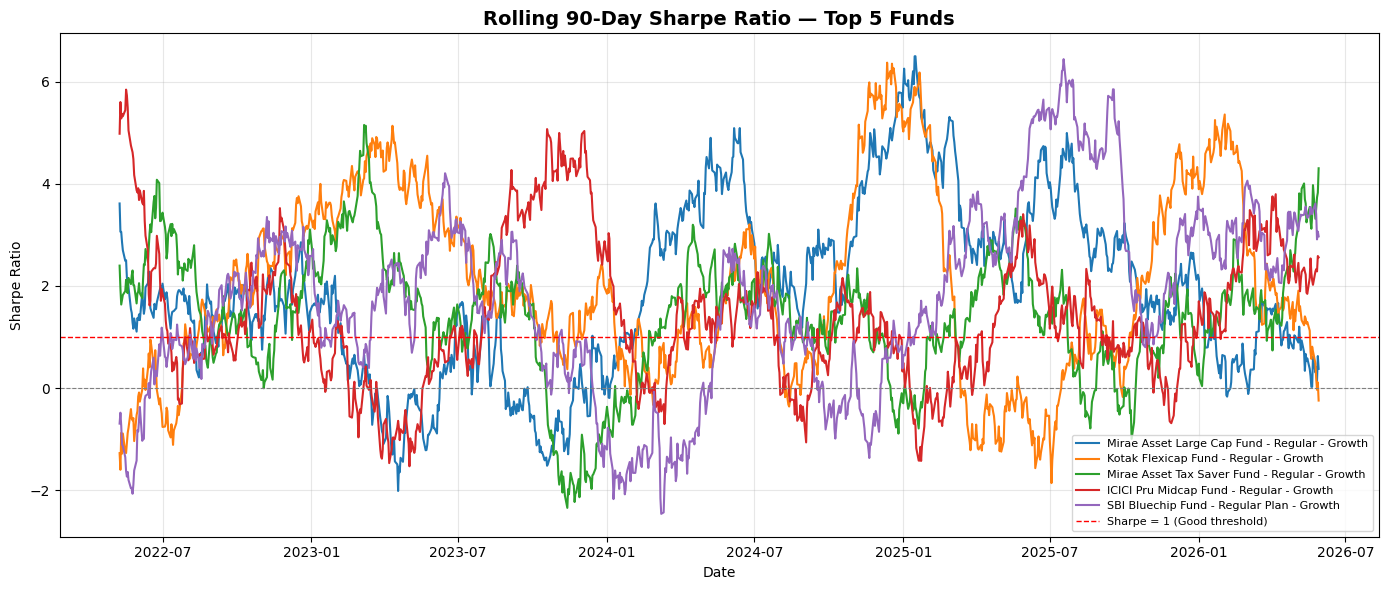

✅ Rolling Sharpe chart saved!


In [8]:
# Pick 5 funds to plot
top5_codes = var_df.nlargest(5, 'sharpe_ratio')['amfi_code'].tolist()
top5_names = var_df.nlargest(5, 'sharpe_ratio')['scheme_name'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for code, name in zip(top5_codes, top5_names):
    fund_returns = nav[nav['amfi_code'] == code].set_index('date')['daily_return']
    
    # Rolling 90-day Sharpe
    rolling_sharpe = (
        fund_returns.rolling(90).mean() /
        fund_returns.rolling(90).std()
    ) * np.sqrt(252)
    
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1.5)

ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Sharpe = 1 (Good threshold)')
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("✅ Rolling Sharpe chart saved!")

In [9]:
# Extract year of first transaction per investor
first_tx = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx.columns = ['investor_id', 'first_tx_date']
first_tx['cohort_year'] = first_tx['first_tx_date'].dt.year

# Merge cohort year back to transactions
transactions = transactions.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id', how='left')

# Cohort analysis
cohort = transactions.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_transaction_amt=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    num_transactions=('investor_id', 'count')
).reset_index()

cohort['avg_transaction_amt'] = cohort['avg_transaction_amt'].round(2)
cohort['total_invested'] = cohort['total_invested'].round(2)

print("✅ Cohort Analysis Done!")
print(cohort)

# Save
cohort.to_csv('../data/processed/cohort_analysis.csv', index=False)
print("✅ Saved to cohort_analysis.csv")

✅ Cohort Analysis Done!
   cohort_year  total_investors  avg_transaction_amt  total_invested  \
0         2024             4803            107422.54      3491125187   
1         2025              197            109158.58        30455243   

   num_transactions  
0             32499  
1               279  
✅ Saved to cohort_analysis.csv


In [10]:
# Filter only SIP transactions
sip_tx = transactions[transactions['transaction_type'] == 'SIP'].copy()

# Sort by investor and date
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

# Compute gap between consecutive SIPs per investor
sip_tx['prev_date'] = sip_tx.groupby('investor_id')['transaction_date'].shift(1)
sip_tx['gap_days'] = (sip_tx['transaction_date'] - sip_tx['prev_date']).dt.days

# Keep only investors with 6+ SIP transactions
sip_counts = sip_tx.groupby('investor_id').size()
active_investors = sip_counts[sip_counts >= 6].index

sip_continuity = sip_tx[sip_tx['investor_id'].isin(active_investors)].groupby('investor_id').agg(
    avg_gap_days=('gap_days', 'mean'),
    num_sips=('transaction_date', 'count')
).reset_index()

# Flag at-risk investors (gap > 35 days)
sip_continuity['status'] = sip_continuity['avg_gap_days'].apply(
    lambda x: 'At Risk' if x > 35 else 'Regular'
)

print("✅ SIP Continuity Analysis Done!")
print(sip_continuity['status'].value_counts())

sip_continuity.to_csv('../data/processed/sip_continuity.csv', index=False)
print("✅ Saved to sip_continuity.csv")

✅ SIP Continuity Analysis Done!
status
At Risk    1332
Regular      30
Name: count, dtype: int64
✅ Saved to sip_continuity.csv


In [13]:
def recommend_funds(risk_appetite):
    """
    Recommends top 3 funds based on investor risk appetite.
    Input: 'Low', 'Moderate', or 'High'
    Output: Top 3 funds by Sharpe ratio within that risk grade
    """
    filtered = performance[
        performance['risk_grade'].str.lower() == risk_appetite.lower()
    ]
    
    if filtered.empty:
        print(f"No funds found for risk appetite: {risk_appetite}")
        return
    
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'sharpe_ratio', 'return_3yr_pct', 'risk_grade']
    ]
    
    print(f"\n✅ Top 3 funds for {risk_appetite} risk investors:")
    print(top3.to_string(index=False))
    return top3

# Test all 3 risk levels
recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


✅ Top 3 funds for Low risk investors:
                             scheme_name  sharpe_ratio  return_3yr_pct risk_grade
ICICI Pru Liquid Fund - Regular - Growth          7.68            7.68        Low
    Kotak Liquid Fund - Regular - Growth          6.18            6.18        Low
     ABSL Liquid Fund - Regular - Growth          5.14            5.14        Low

✅ Top 3 funds for Moderate risk investors:
                                  scheme_name  sharpe_ratio  return_3yr_pct risk_grade
    HDFC Top 100 Fund - Regular Plan - Growth          1.06           14.84   Moderate
Mirae Asset Large Cap Fund - Regular - Growth          1.06           14.81   Moderate
    ICICI Pru Bluechip Fund - Direct - Growth          1.03           14.41   Moderate

✅ Top 3 funds for High risk investors:
                                  scheme_name  sharpe_ratio  return_3yr_pct risk_grade
Kotak Emerging Equity Fund - Regular - Growth          0.96           18.23       High
     ICICI Pru Midcap Fund 

,scheme_name,sharpe_ratio,return_3yr_pct,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,0.96,18.23,High
12,ICICI Pru Midcap Fund - Regular - Growth,0.95,18.08,High
38,DSP Midcap Fund - Regular - Growth,0.90,17.16,High
